In [94]:
import pandas as pd
import numpy as np
df = pd.read_excel('US Superstore data.xls')
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [95]:
# to get to know the missing data
df.info() # no missing data

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [96]:
# Which states have the most sales?
print(df['State'].unique().tolist())
print(len(df['State'].unique()))
# print(df['State'].value_counts())
# group by states and get sum of sales per state
sales_per_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

print(f'State with the most sales: {sales_per_state.idxmax()} - {sales_per_state.max()}')

['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska', 'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware', 'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee', 'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio', 'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut', 'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island', 'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland', 'District of Columbia', 'Kansas', 'Vermont', 'Maine', 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming', 'West Virginia']
49
State with the most sales: California - 457687.6315


In [97]:
# What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
df_groupby_state = df.groupby('State')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
ca_sales = df_groupby_state.loc['California']['Sales']
ca_profit = df_groupby_state.loc['California']['Profit']
print(f'California Sales: {ca_sales}, Profit: {ca_profit}')
ny_sales = df_groupby_state.loc['New York']['Sales']
ny_profit = df_groupby_state.loc['New York']['Profit']
print(f'New York Sales: {ny_sales}, Profit: {ny_profit}')
print(f'California has {(ca_sales - ny_sales):.2f} more sales and {(ca_profit - ny_profit):.2f} more profit than New York')
# option 2:
ca_sales = df[df['State'] == 'California']['Sales'].sum()
ca_profit = df[df['State'] == 'New York']['Profit'].sum()


California Sales: 457687.6315, Profit: 76381.38709999999
New York Sales: 310876.271, Profit: 74038.5486
California has 146811.36 more sales and 2342.84 more profit than New York


In [98]:
# Who is an outstanding customer in New York?
df_ny = df[df['State'] == 'New York']
ny_customer_sales = df_ny.groupby(by='Customer Name')['Sales'].sum().sort_values(ascending=False)
print(f'{ny_customer_sales.idxmax()} is the most outstanding customer in New York with total sales of {ny_customer_sales.max():.2f}')

Tom Ashbrook is the most outstanding customer in New York with total sales of 13723.50


In [99]:
# Are there any differences among states in profitability?
df_groupby_state.head()
df_groupby_state['Profit_Margin'] = (df_groupby_state['Profit'] / df_groupby_state['Sales']) * 100
df_groupby_state.sort_values(by='Profit_Margin', ascending=False).head(20)

,Sales,Profit,Profit_Margin
State,,,
District of Columbia,2865.020,1059.5893,36.983662
Delaware,27451.069,9977.3748,36.346034
Minnesota,29863.150,10823.1874,36.242618
Maine,1270.530,454.4862,35.771387
Arkansas,11678.130,4008.6871,34.326447
Indiana,53555.360,18382.9363,34.325110
Georgia,49095.840,16250.0433,33.098615
Montana,5589.352,1833.3285,32.800377
Rhode Island,22627.956,7285.6293,32.197470


In [ ]:
# Identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit
# group by product and sum the sales
product_sales = df.groupby('Product ID')['Sales'].sum().reset_index()
print(product_sales.info())
print(len(product_sales))
product_sales = product_sales.sort_values('Sales', ascending=False).reset_index(drop=True)
product_sales['Cumulative_Sales'] = product_sales['Sales'].cumsum()
total_sales = product_sales['Sales'].sum()
product_sales['Cumulative_Percentage'] = (product_sales['Cumulative_Sales'] / total_sales) * 100
# product_sales['Product_Percentage'] = (np.arange(1, len(product_sales) + 1) / len(product_sales)) * 100

print(product_sales.head(36))
product_at_80_percentage_sales = product_sales[product_sales['Cumulative_Percentage'] >= 80].iloc[0]

print(product_at_80_percentage_sales)
its_index = product_at_80_percentage_sales.name
percentage_of_this_product_in_total = ((its_index + 1) / len(product_sales)) * 100
print(percentage_of_this_product_in_total)
print(f'around {percentage_of_this_product_in_total:.2f}% of products generate 80% of the sales')



<class 'pandas.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Product ID  1862 non-null   str    
 1   Sales       1862 non-null   float64
dtypes: float64(1), str(1)
memory usage: 29.2 KB
None
1862
         Product ID       Sales  Cumulative_Sales  Cumulative_Percentage
0   TEC-CO-10004722  61599.8240        61599.8240               2.681517
1   OFF-BI-10003527  27453.3840        89053.2080               3.876596
2   TEC-MA-10002412  22638.4800       111691.6880               4.862078
3   FUR-CH-10002024  21870.5760       133562.2640               5.814131
4   OFF-BI-10001359  19823.4790       153385.7430               6.677071
5   OFF-BI-10000545  19024.5000       172410.2430               7.505232
6   TEC-CO-10001449  18839.6860       191249.9290               8.325346
7   TEC-MA-10001127  18374.8950       209624.8240               9.125228
8   OFF-BI-10004995  1796

In [137]:
# Same operations for customer and profit

customer_profit = df.groupby('Customer ID')['Profit'].sum().reset_index()
customer_profit = customer_profit.sort_values('Profit', ascending=False).reset_index(drop=True)
customer_profit.columns = ['Customer', 'Profit']
customer_profit['Cumulative_Profit'] = customer_profit['Profit'].cumsum()
total_profit = customer_profit.iloc[-1]['Cumulative_Profit']
print(total_profit)
customer_profit['Cumulative_Percentage'] = (customer_profit['Cumulative_Profit'] / total_profit) * 100
customer_at_80_percent_profit = customer_profit[customer_profit['Cumulative_Percentage'] >= 80].iloc[0]
customer_profit.head()
print(customer_at_80_percent_profit)
its_location = customer_at_80_percent_profit.name + 1
location_percentage = (its_location / len(customer_profit)) * 100
print(f'around {location_percentage:.2f}% of customers generate 80% profits')

286397.0216999998
Customer                    KC-16540
Profit                      709.4219
Cumulative_Profit        229705.2754
Cumulative_Percentage       80.20519
Name: 152, dtype: object
around 19.29% of customers generate 80% profits


In [ ]:
# What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? 
# (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

df_groupby_cities = df.groupby('City')[['Sales', 'Profit']].sum().reset_index()
df_groupby_cities = df_groupby_cities.sort_values('Sales', ascending=False).reset_index(drop=True)
# top 20 cities by sales
top_20_cities_by_sales = df_groupby_cities[:20]
top_20_cities_by_sales['Profit_margin'] = (top_20_cities_by_sales['Profit'] / top_20_cities_by_sales['Sales']) * 100
print(top_20_cities_by_sales.head(20))
print('Top selling cities do not necessarily have the best profitability, for example, Philadelphia, Houston, Chicago have very high sales, but they dont profit at all')
# top 20 cities by profit
df_groupby_cities = df_groupby_cities.sort_values('Profit', ascending=False).reset_index(drop=True)
top_20_cities_by_profit = df_groupby_cities[:20]
top_20_cities_by_profit['Profit_margin'] = (top_20_cities_by_profit['Profit'] / top_20_cities_by_profit['Sales']) * 100
print(top_20_cities_by_profit.head(20))
print('Top 20 profit cities also dont necessarily have the highest sales, but they have high profitability')


             City        Sales      Profit  Profit_margin
0   New York City  256368.1610  62036.9837      24.198396
1     Los Angeles  175851.3410  30440.7579      17.310507
2         Seattle  119540.7420  29156.0967      24.390092
3   San Francisco  112669.0920  17507.3854      15.538765
4    Philadelphia  109077.0130 -13837.7674     -12.686236
5         Houston   64504.7604 -10153.5485     -15.740774
6         Chicago   48539.5410  -6654.5688     -13.709583
7       San Diego   47521.0290   6377.1960      13.419735
8    Jacksonville   44713.1830  -2323.8350      -5.197203
9     Springfield   43054.3420   6200.6974      14.402026
10        Detroit   42446.9440  13181.7908      31.054746
11       Columbus   38706.2430   5897.1013      15.235530
12         Newark   28576.1190   5793.7588      20.274827
13       Columbia   25283.3240   5606.1167      22.173179
14      Lafayette   25036.2000  10018.3876      40.015608
15        Jackson   24963.8580   7581.6828      30.370637
16    San Anto

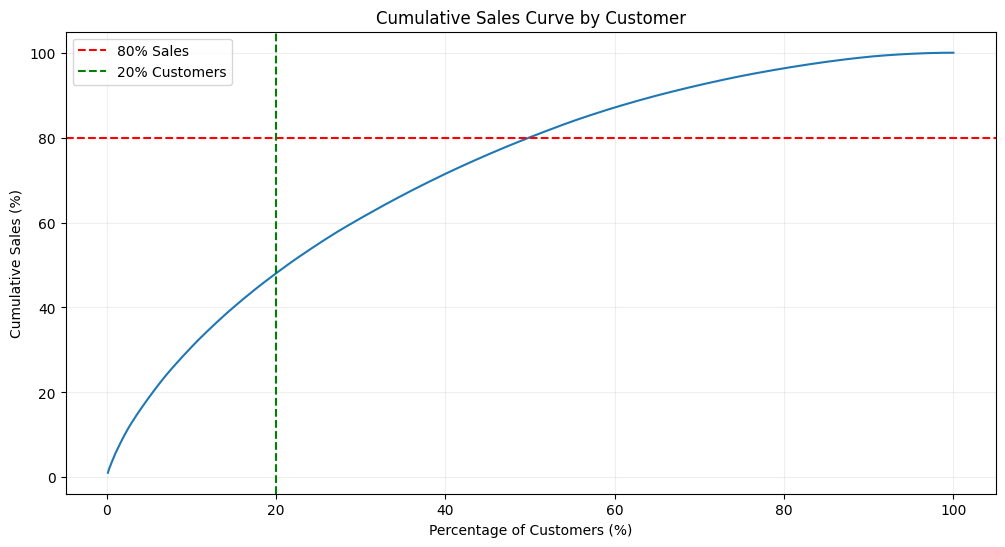

as we can see from the chart, 80% of sales need around 50% customer
and 20% of customers only generate 50% of sales


In [175]:
# What are the Top 20 customers by Sales?
import matplotlib.pyplot as plt
df_groupby_customer = df.groupby('Customer Name')['Sales'].sum().reset_index()
df_groupby_customer = df_groupby_customer.sort_values('Sales', ascending=False).reset_index(drop=True)
df_groupby_customer['Cumulative_sales'] = df_groupby_customer['Sales'].cumsum()
df_groupby_customer['Cumulative_percent'] = (df_groupby_customer['Cumulative_sales'] / df_groupby_customer['Sales'].sum()) * 100
df_groupby_customer['customer_index_percentage'] = (np.arange(1, len(df_groupby_customer)+1) / len(df_groupby_customer)) * 100
df_groupby_customer.head(20)
plt.figure(figsize=(12, 6))
plt.plot(df_groupby_customer['customer_index_percentage'], df_groupby_customer['Cumulative_percent'])
plt.xlabel('Percentage of Customers (%)')
plt.ylabel('Cumulative Sales (%)')
plt.title('Cumulative Sales Curve by Customer')
plt.grid(True, alpha=0.2)
plt.axhline(y=80, color='r', linestyle='--', label='80% Sales')
plt.axvline(x=20, color='g', linestyle='--', label='20% Customers')
plt.legend()
plt.show()

print('as we can see from the chart, 80% of sales need around 50% customer')
print('and 20% of customers only generate 50% of sales')
